# Phase 2 — Exploratory Data Analysis

This notebook explores the main patterns in the cleaned and feature-engineered
NYC Taxi Fare dataset.

The analysis focuses on three main questions:

1. How does trip distance relate to taxi fare?
2. How do temporal patterns affect fare and trip demand?
3. How are taxi trips geographically distributed across New York City?

The full feature-engineered dataset contains more than 54 million records.
To avoid excessive memory usage, visualization-heavy analyses use a reproducible
sample, while full-dataset aggregation will be used where exact statistics are required.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------
# Paths
# -------------------------

DATA_PATH = Path("../data/processed/train_features.csv")

EDA_SAMPLE_PATH = Path(
    "../data/processed/eda_sample_300k.csv"
)

FIGURE_DIR = Path(
    "../reports/figures/week2"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# -------------------------
# Dataset configuration
# -------------------------

TOTAL_ROWS = 54_004_358

CHUNK_SIZE = 500_000
TARGET_SAMPLE_SIZE = 300_000
RANDOM_STATE = 42


# -------------------------
# Plot configuration
# -------------------------

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

## Sampling Strategy

The full dataset is too large to load into memory for interactive exploratory
analysis.

A reproducible sample of approximately 300,000 records is therefore created
using proportional sampling across chunks of the full dataset.

The sample is saved locally so that subsequent notebook runs do not need to
scan the full 6.4 GB dataset again.

Full-dataset aggregation will still be used later for statistics where exact
counts or averages are required.

In [2]:
def sample_large_csv(
    path,
    total_rows,
    target_sample_size=300_000,
    chunksize=500_000,
    random_state=42,
):
    """
    Proportionally sample a large CSV.

    Each row has approximately the same probability of being
    selected regardless of which chunk it belongs to.
    """

    # Slight oversampling ensures that we can obtain
    # exactly target_sample_size rows at the end.
    sample_fraction = min(
        1.0,
        (target_sample_size / total_rows) * 1.02
    )

    sampled_chunks = []

    for i, chunk in enumerate(
        pd.read_csv(
            path,
            chunksize=chunksize
        )
    ):
        sampled = chunk.sample(
            frac=sample_fraction,
            random_state=random_state + i
        )

        sampled_chunks.append(sampled)

    df_sample = pd.concat(
        sampled_chunks,
        ignore_index=True
    )

    if len(df_sample) >= target_sample_size:
        df_sample = df_sample.sample(
            n=target_sample_size,
            random_state=random_state
        )

    return df_sample.reset_index(drop=True)

In [3]:
if EDA_SAMPLE_PATH.exists():

    print("Loading existing EDA sample...")

    df = pd.read_csv(
        EDA_SAMPLE_PATH
    )

else:

    print("Creating EDA sample from full dataset...")

    df = sample_large_csv(
        DATA_PATH,
        total_rows=TOTAL_ROWS,
        target_sample_size=TARGET_SAMPLE_SIZE,
        chunksize=CHUNK_SIZE,
        random_state=RANDOM_STATE,
    )

    df.to_csv(
        EDA_SAMPLE_PATH,
        index=False
    )

    print(
        f"Sample saved to: {EDA_SAMPLE_PATH}"
    )


print(
    f"EDA sample size: {len(df):,}"
)

print(
    f"Shape: {df.shape}"
)

Loading existing EDA sample...
EDA sample size: 300,000
Shape: (300000, 12)


In [4]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance,pickup_hour,day_of_week,is_weekend
0,2009-01-31 01:09:00.000000167,10.9,2009-01-31 01:09:00 UTC,-73.968408,40.762917,-73.982988,40.721845,1,4.729303,1,5,1
1,2011-12-15 21:22:44.0000002,10.5,2011-12-15 21:22:44 UTC,-73.954191,40.766362,-73.977555,40.729232,1,4.573808,21,3,0
2,2011-02-06 23:40:00.000000107,4.1,2011-02-06 23:40:00 UTC,-74.002688,40.733808,-74.008865,40.725967,2,1.015425,23,6,1
3,2011-07-26 07:51:00.00000097,6.1,2011-07-26 07:51:00 UTC,-73.990537,40.743330,-74.001322,40.756413,2,1.715144,7,1,0
4,2010-03-17 09:29:32.0000005,2.9,2010-03-17 09:29:32 UTC,-73.964496,40.759624,-73.964496,40.759624,3,0.000000,9,2,0


## Sample Validation

Before performing exploratory analysis, the EDA sample is checked for:

- expected feature columns;
- missing values;
- valid temporal feature ranges;
- fare and distance distributions;
- consistency with the earlier development sample.

In [5]:
analysis_columns = [
    "fare_amount",
    "trip_distance",
    "pickup_hour",
    "day_of_week",
    "is_weekend",
    "passenger_count",
]

df[analysis_columns].describe()

,fare_amount,trip_distance,pickup_hour,day_of_week,is_weekend,passenger_count
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,11.338593,3.319089,13.504557,3.042420,0.283373,1.689703
std,9.707806,3.580261,6.510910,1.949733,0.450637,1.305426
min,2.500000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,6.000000,1.253021,9.000000,1.000000,0.000000,1.000000
50%,8.500000,2.151307,14.000000,3.000000,0.000000,1.000000
75%,12.500000,3.924540,19.000000,5.000000,1.000000,2.000000
max,900.000000,38.660372,23.000000,6.000000,1.000000,6.000000


In [6]:
print("=== Missing Values ===")

print(
    df[
        [
            "fare_amount",
            "trip_distance",
            "pickup_hour",
            "day_of_week",
            "is_weekend",
        ]
    ]
    .isna()
    .sum()
)

=== Missing Values ===
fare_amount      0
trip_distance    0
pickup_hour      0
day_of_week      0
is_weekend       0
dtype: int64


In [7]:
print("Fare quantiles:")

print(
    df["fare_amount"].quantile(
        [
            0,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            1.00,
        ]
    )
)


print("\nDistance quantiles:")

print(
    df["trip_distance"].quantile(
        [
            0,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            1.00,
        ]
    )
)

Fare quantiles:
0.00      2.50
0.25      6.00
0.50      8.50
0.75     12.50
0.95     30.33
0.99     53.00
1.00    900.00
Name: fare_amount, dtype: float64

Distance quantiles:
0.00     0.000000
0.25     1.253021
0.50     2.151307
0.75     3.924540
0.95    10.030908
0.99    20.326212
1.00    38.660372
Name: trip_distance, dtype: float64


## Trip Distance and Fare Amount

The first major analysis examines the relationship between trip distance
and taxi fare.

Trip distance is calculated using the Haversine distance between pickup
and drop-off coordinates. Therefore, it represents straight-line geographic
distance rather than the actual road distance travelled by the taxi.

Both Pearson and Spearman correlations are considered because fare and
distance contain skewed distributions and extreme values.

In [8]:
pearson_corr = (
    df[
        [
            "fare_amount",
            "trip_distance",
        ]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)


spearman_corr = (
    df[
        [
            "fare_amount",
            "trip_distance",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)


print(
    f"Pearson correlation:  {pearson_corr:.4f}"
)

print(
    f"Spearman correlation: {spearman_corr:.4f}"
)

Pearson correlation:  0.8535
Spearman correlation: 0.8466


### Key Finding

Trip distance has a strong positive relationship with taxi fare. The Pearson
correlation is 0.8535 and the Spearman correlation is 0.8466, indicating that
the relationship is both strongly linear and consistently monotonic across
the sampled trips.

Most trips are concentrated in the short-distance and lower-fare region,
while longer trips generally correspond to higher fares. However, the
relationship is not perfectly linear, and several fare bands remain visible,
suggesting that additional factors may also influence the final fare.

The Haversine distance used here represents straight-line geographic distance
rather than the actual driven route, so it should be interpreted as a proxy
for trip length.

### Scatter Plot

A conventional scatter plot is first used to inspect the relationship.

Only a subset of the EDA sample is displayed because plotting hundreds of
thousands of individual points creates severe overplotting.

The axis limits are used only for visualization and do not remove observations
from the dataset.

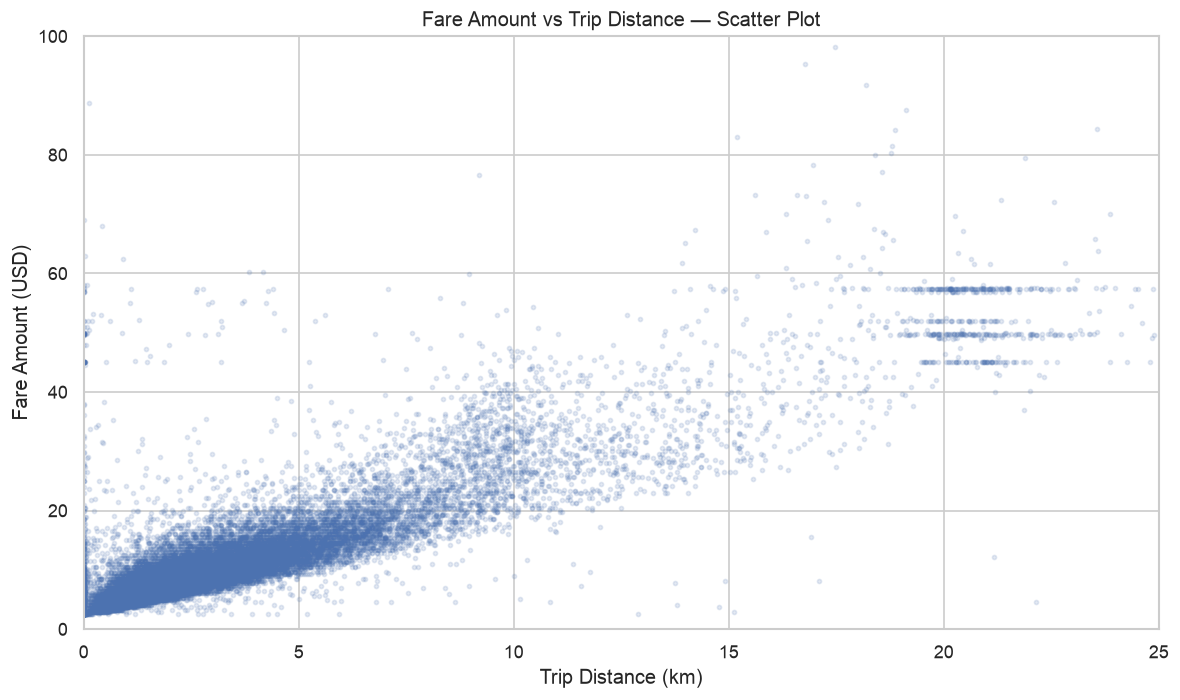

In [9]:
scatter_sample = df.sample(
    n=30_000,
    random_state=RANDOM_STATE
)


plt.figure(figsize=(10, 6))

plt.scatter(
    scatter_sample["trip_distance"],
    scatter_sample["fare_amount"],
    s=6,
    alpha=0.15,
)

plt.xlabel(
    "Trip Distance (km)"
)

plt.ylabel(
    "Fare Amount (USD)"
)

plt.title(
    "Fare Amount vs Trip Distance — Scatter Plot"
)

plt.xlim(
    0,
    25
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.show()

### Density-based Visualization

Because many taxi trips occupy similar distance–fare combinations, a hexbin
plot provides a clearer representation of the underlying relationship.

Each hexagonal region represents the number of observations within that
distance–fare range. A logarithmic count scale is used because trip density
varies substantially across the plot.

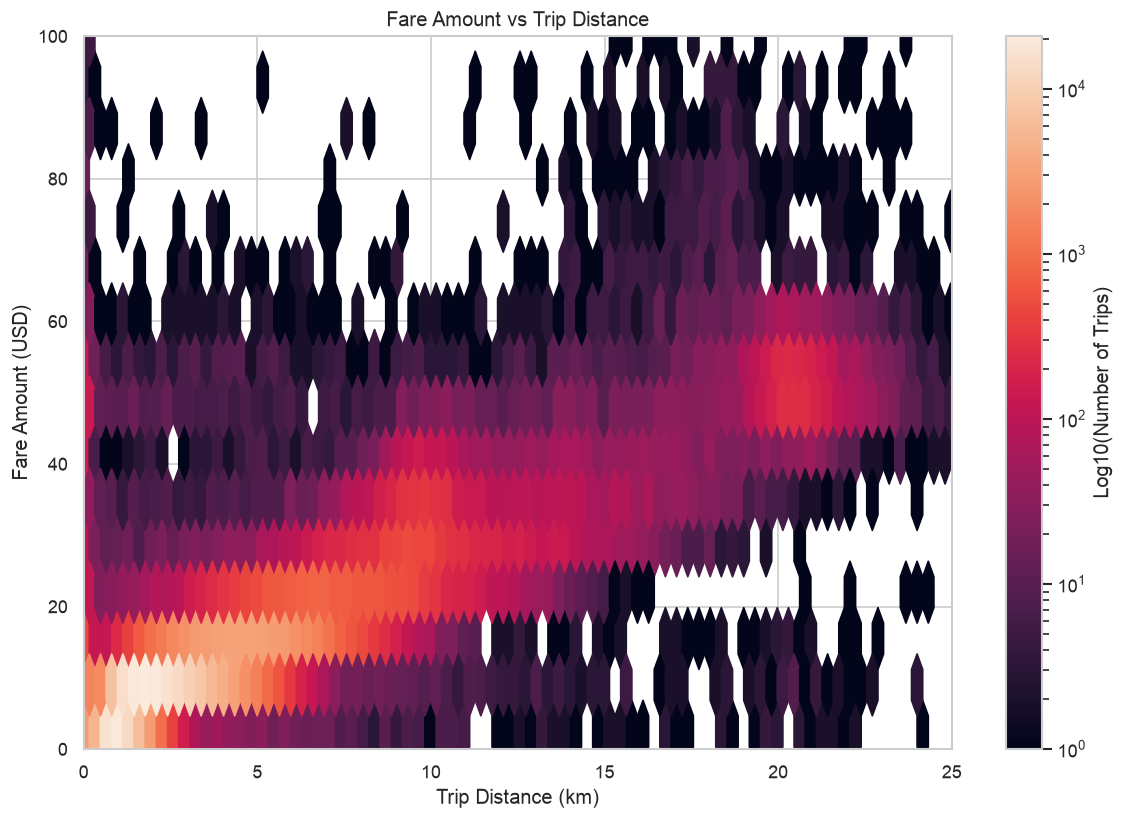

In [10]:
plt.figure(figsize=(10, 7))

hb = plt.hexbin(
    df["trip_distance"],
    df["fare_amount"],
    gridsize=120,
    mincnt=1,
    bins="log",
)

plt.colorbar(
    hb,
    label="Log10(Number of Trips)"
)

plt.xlabel(
    "Trip Distance (km)"
)

plt.ylabel(
    "Fare Amount (USD)"
)

plt.title(
    "Fare Amount vs Trip Distance"
)

plt.xlim(
    0,
    25
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fare_vs_distance_hexbin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Zero-distance Trips

A small proportion of records have a calculated trip distance of zero.

These records are retained in the feature-engineered dataset because a zero
Haversine distance does not necessarily imply an invalid taxi transaction.
Possible explanations include identical recorded pickup/drop-off coordinates,
coordinate precision limitations, very short trips, or data-recording issues.

Their influence on the fare-distance relationship is therefore examined
separately rather than automatically removing them.

In [11]:
zero_distance = (
    df["trip_distance"] == 0
)

very_short_distance = (
    df["trip_distance"] <= 0.1
)


print(
    f"Zero-distance trips: "
    f"{zero_distance.sum():,} "
    f"({zero_distance.mean():.2%})"
)

print(
    f"Trips <= 0.1 km: "
    f"{very_short_distance.sum():,} "
    f"({very_short_distance.mean():.2%})"
)


print("\nFare summary for zero-distance trips:")

print(
    df.loc[
        zero_distance,
        "fare_amount"
    ].describe()
)

Zero-distance trips: 3,011 (1.00%)
Trips <= 0.1 km: 4,774 (1.59%)

Fare summary for zero-distance trips:
count    3011.000000
mean       11.028064
std        21.556899
min         2.500000
25%         4.900000
50%         6.900000
75%        10.100000
max       900.000000
Name: fare_amount, dtype: float64


# Temporal Patterns

This section examines how NYC taxi demand and fare patterns vary throughout
the day.

Three metrics are considered for each pickup hour:

- trip volume;
- average fare;
- average trip distance.

Temporal features are extracted directly from the pickup_datetime values
provided in the Kaggle dataset.

Full-dataset aggregation is used here because hourly statistics can be
calculated efficiently without loading the complete dataset into memory.

In [12]:
HOURLY_STATS_PATH = Path(
    "../reports/hourly_stats.csv"
)


def compute_hourly_statistics(
    path,
    chunksize=1_000_000,
):
    """
    Compute exact hourly statistics from the full feature dataset
    using chunk-based aggregation.
    """

    hourly_parts = []

    for i, chunk in enumerate(
        pd.read_csv(
            path,
            usecols=[
                "pickup_hour",
                "fare_amount",
                "trip_distance",
            ],
            chunksize=chunksize,
        ),
        start=1,
    ):

        grouped = (
            chunk
            .groupby("pickup_hour")
            .agg(
                trip_count=("fare_amount", "size"),
                fare_sum=("fare_amount", "sum"),
                distance_sum=("trip_distance", "sum"),
            )
        )

        hourly_parts.append(grouped)

        print(
            f"Processed chunk {i}"
        )

    hourly = (
        pd.concat(hourly_parts)
        .groupby(level=0)
        .sum()
        .sort_index()
    )

    hourly["avg_fare"] = (
        hourly["fare_sum"]
        / hourly["trip_count"]
    )

    hourly["avg_distance"] = (
        hourly["distance_sum"]
        / hourly["trip_count"]
    )

    return hourly[
        [
            "trip_count",
            "avg_fare",
            "avg_distance",
        ]
    ]

In [13]:
if HOURLY_STATS_PATH.exists():

    print("Loading existing hourly statistics...")

    hourly_stats = pd.read_csv(
        HOURLY_STATS_PATH,
        index_col="pickup_hour",
    )

else:

    print("Computing hourly statistics from full dataset...")

    hourly_stats = compute_hourly_statistics(
        DATA_PATH,
        chunksize=1_000_000,
    )

    hourly_stats.to_csv(
        HOURLY_STATS_PATH
    )

    print(
        f"Saved to: {HOURLY_STATS_PATH}"
    )


hourly_stats

Loading existing hourly statistics...


,trip_count,avg_fare,avg_distance
pickup_hour,,,
0,2137965,11.634956,3.746957
1,1583491,11.364496,3.732829
2,1180812,11.341924,3.787187
3,865189,11.804288,3.990062
4,626831,13.544978,4.635047
5,527879,15.112927,5.177748
6,1107975,12.137950,4.050543
7,1944867,10.959014,3.363392
8,2453287,10.922168,3.021333


In [14]:
print("=== Hourly Statistics ===")
print(hourly_stats.round(3))

print("\n=== Key Hours ===")

busiest_hour = hourly_stats["trip_count"].idxmax()
quietest_hour = hourly_stats["trip_count"].idxmin()

highest_fare_hour = hourly_stats["avg_fare"].idxmax()
lowest_fare_hour = hourly_stats["avg_fare"].idxmin()

longest_trip_hour = hourly_stats["avg_distance"].idxmax()
shortest_trip_hour = hourly_stats["avg_distance"].idxmin()

print(
    f"Busiest hour: {busiest_hour}:00 "
    f"({hourly_stats.loc[busiest_hour, 'trip_count']:,.0f} trips)"
)

print(
    f"Quietest hour: {quietest_hour}:00 "
    f"({hourly_stats.loc[quietest_hour, 'trip_count']:,.0f} trips)"
)

print(
    f"Highest average fare: {highest_fare_hour}:00 "
    f"(${hourly_stats.loc[highest_fare_hour, 'avg_fare']:.2f})"
)

print(
    f"Lowest average fare: {lowest_fare_hour}:00 "
    f"(${hourly_stats.loc[lowest_fare_hour, 'avg_fare']:.2f})"
)

print(
    f"Longest average trip: {longest_trip_hour}:00 "
    f"({hourly_stats.loc[longest_trip_hour, 'avg_distance']:.2f} km)"
)

=== Hourly Statistics ===
             trip_count  avg_fare  avg_distance
pickup_hour                                    
0               2137965    11.635         3.747
1               1583491    11.364         3.733
2               1180812    11.342         3.787
3                865189    11.804         3.990
4                626831    13.545         4.635
5                527879    15.113         5.178
6               1107975    12.138         4.051
7               1944867    10.959         3.363
8               2453287    10.922         3.021
9               2524703    10.869         2.906
10              2436888    10.892         2.951
11              2514558    11.111         2.985
12              2656213    11.099         2.967
13              2639934    11.490         3.126
14              2719807    11.840         3.235
15              2596961    11.935         3.284
16              2228719    11.845         3.339
17              2675843    11.465         3.190
18            

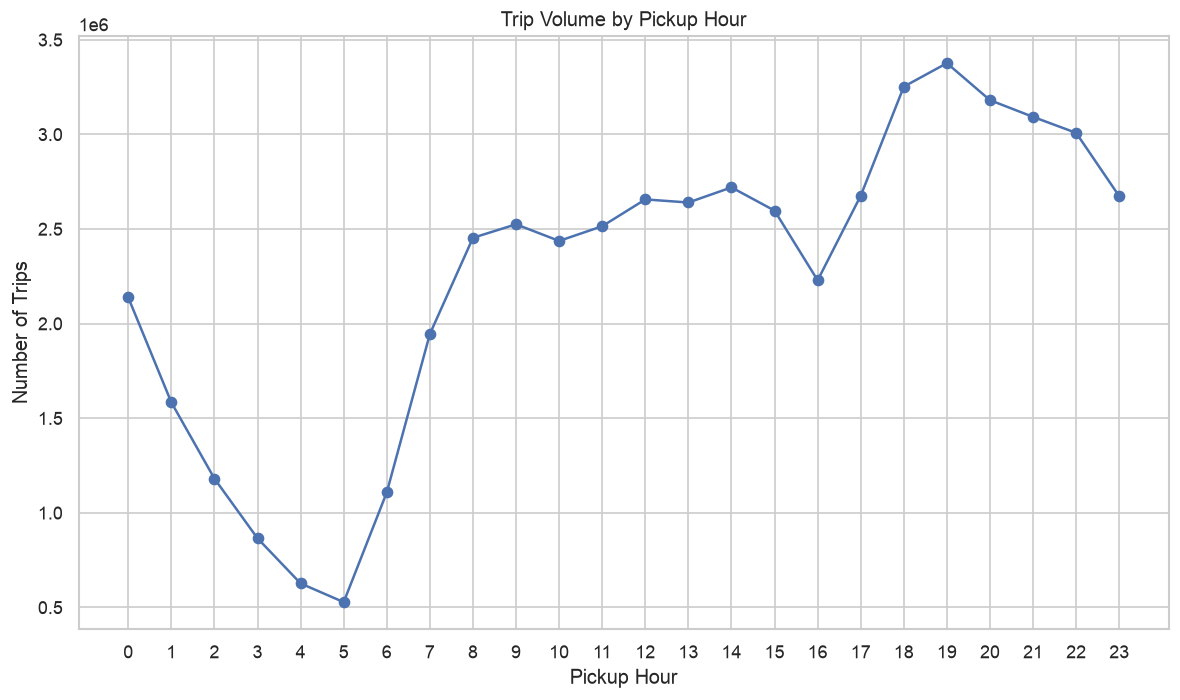

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_stats.index,
    hourly_stats["trip_count"],
    marker="o",
)

plt.xticks(
    range(24)
)

plt.xlabel(
    "Pickup Hour"
)

plt.ylabel(
    "Number of Trips"
)

plt.title(
    "Trip Volume by Pickup Hour"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "trip_volume_by_hour.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

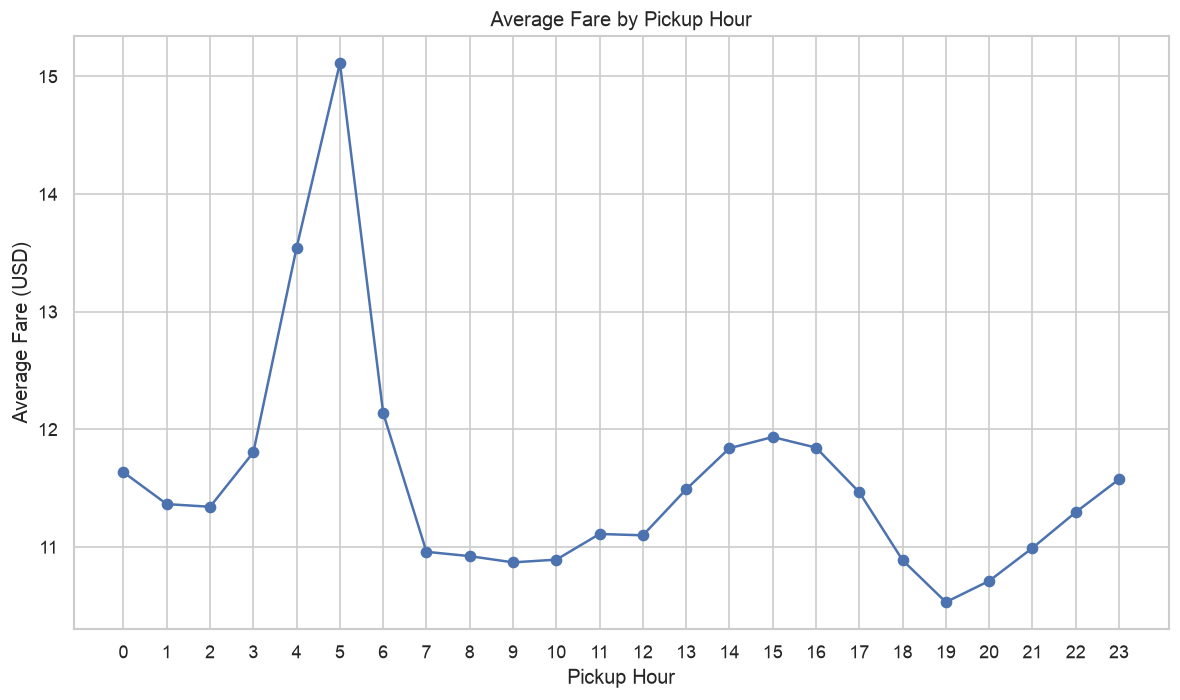

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_stats.index,
    hourly_stats["avg_fare"],
    marker="o",
)

plt.xticks(
    range(24)
)

plt.xlabel(
    "Pickup Hour"
)

plt.ylabel(
    "Average Fare (USD)"
)

plt.title(
    "Average Fare by Pickup Hour"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "average_fare_by_hour.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

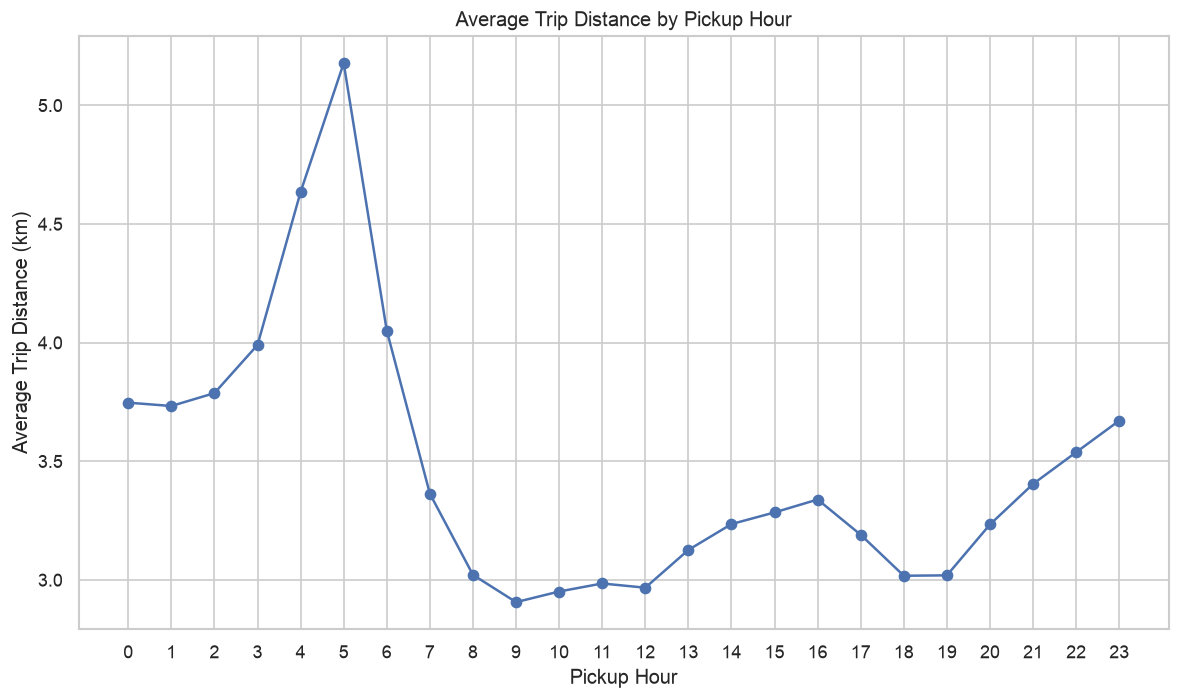

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_stats.index,
    hourly_stats["avg_distance"],
    marker="o",
)

plt.xticks(
    range(24)
)

plt.xlabel(
    "Pickup Hour"
)

plt.ylabel(
    "Average Trip Distance (km)"
)

plt.title(
    "Average Trip Distance by Pickup Hour"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "average_distance_by_hour.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Key Finding

Taxi demand and average fare show distinct hourly patterns.

Trip volume reaches its highest level in the early evening, around 19:00,
while the lowest demand occurs in the early morning around 05:00.

In contrast, the highest average fares occur during the early morning.
This pattern closely follows the average trip distance: trips around 04:00–06:00
are substantially longer than those during most daytime hours.

This suggests that the higher average fares observed in the early morning are
strongly associated with longer trip distances rather than simply higher demand.

Therefore, peak taxi demand and peak average fare occur at different times of day.

## Day-of-Week Patterns

This section examines whether taxi demand, average fare, and average trip
distance vary across the days of the week.

Full-dataset aggregation is used because the resulting statistics contain
only seven groups and can therefore be calculated exactly without loading
the full dataset into memory.

In [18]:
DAY_OF_WEEK_STATS_PATH = Path(
    "../reports/day_of_week_stats.csv"
)

DAY_NAMES = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}


def compute_day_of_week_statistics(
    path,
    chunksize=1_000_000,
):
    """Compute exact day-of-week statistics in chunks."""

    parts = []

    for i, chunk in enumerate(
        pd.read_csv(
            path,
            usecols=[
                "day_of_week",
                "fare_amount",
                "trip_distance",
            ],
            chunksize=chunksize,
        ),
        start=1,
    ):
        grouped = (
            chunk
            .groupby("day_of_week")
            .agg(
                trip_count=("fare_amount", "size"),
                fare_sum=("fare_amount", "sum"),
                distance_sum=("trip_distance", "sum"),
            )
        )

        parts.append(grouped)
        print(f"Processed chunk {i}")

    stats = (
        pd.concat(parts)
        .groupby(level=0)
        .sum()
        .sort_index()
    )

    stats["avg_fare"] = (
        stats["fare_sum"]
        / stats["trip_count"]
    )

    stats["avg_distance"] = (
        stats["distance_sum"]
        / stats["trip_count"]
    )

    return stats[
        [
            "trip_count",
            "avg_fare",
            "avg_distance",
        ]
    ]

In [19]:
if DAY_OF_WEEK_STATS_PATH.exists():

    print("Loading existing day-of-week statistics...")

    day_of_week_stats = pd.read_csv(
        DAY_OF_WEEK_STATS_PATH,
        index_col="day_of_week",
    )

else:

    print("Computing day-of-week statistics from full dataset...")

    day_of_week_stats = compute_day_of_week_statistics(
        DATA_PATH,
        chunksize=1_000_000,
    )

    day_of_week_stats.to_csv(
        DAY_OF_WEEK_STATS_PATH
    )

    print(
        f"Saved to: {DAY_OF_WEEK_STATS_PATH}"
    )


assert (
    day_of_week_stats["trip_count"].sum()
    == TOTAL_ROWS
)

day_of_week_stats.rename(
    index=DAY_NAMES
)

Loading existing day-of-week statistics...


,trip_count,avg_fare,avg_distance
day_of_week,,,
Monday,6922341,11.331165,3.374353
Tuesday,7565474,11.165958,3.205536
Wednesday,7834743,11.267555,3.211957
Thursday,8090284,11.451239,3.271498
Friday,8308658,11.380657,3.268358
Saturday,8197684,10.957285,3.269605
Sunday,7085174,11.607066,3.595620


In [20]:
print("=== Day-of-Week Statistics ===")
print(
    day_of_week_stats
    .rename(index=DAY_NAMES)
    .round(3)
)

print("\n=== Key Days ===")

day_metrics = {
    "Busiest day": ("trip_count", "idxmax"),
    "Quietest day": ("trip_count", "idxmin"),
    "Highest average fare day": ("avg_fare", "idxmax"),
    "Lowest average fare day": ("avg_fare", "idxmin"),
    "Longest average trip day": ("avg_distance", "idxmax"),
    "Shortest average trip day": ("avg_distance", "idxmin"),
}

for label, (column, method) in day_metrics.items():
    day_number = getattr(
        day_of_week_stats[column],
        method,
    )()
    print(
        f"{label}: {DAY_NAMES[day_number]}"
    )

=== Day-of-Week Statistics ===
             trip_count  avg_fare  avg_distance
day_of_week                                    
Monday          6922341    11.331         3.374
Tuesday         7565474    11.166         3.206
Wednesday       7834743    11.268         3.212
Thursday        8090284    11.451         3.271
Friday          8308658    11.381         3.268
Saturday        8197684    10.957         3.270
Sunday          7085174    11.607         3.596

=== Key Days ===
Busiest day: Friday
Quietest day: Monday
Highest average fare day: Sunday
Lowest average fare day: Saturday
Longest average trip day: Sunday
Shortest average trip day: Tuesday


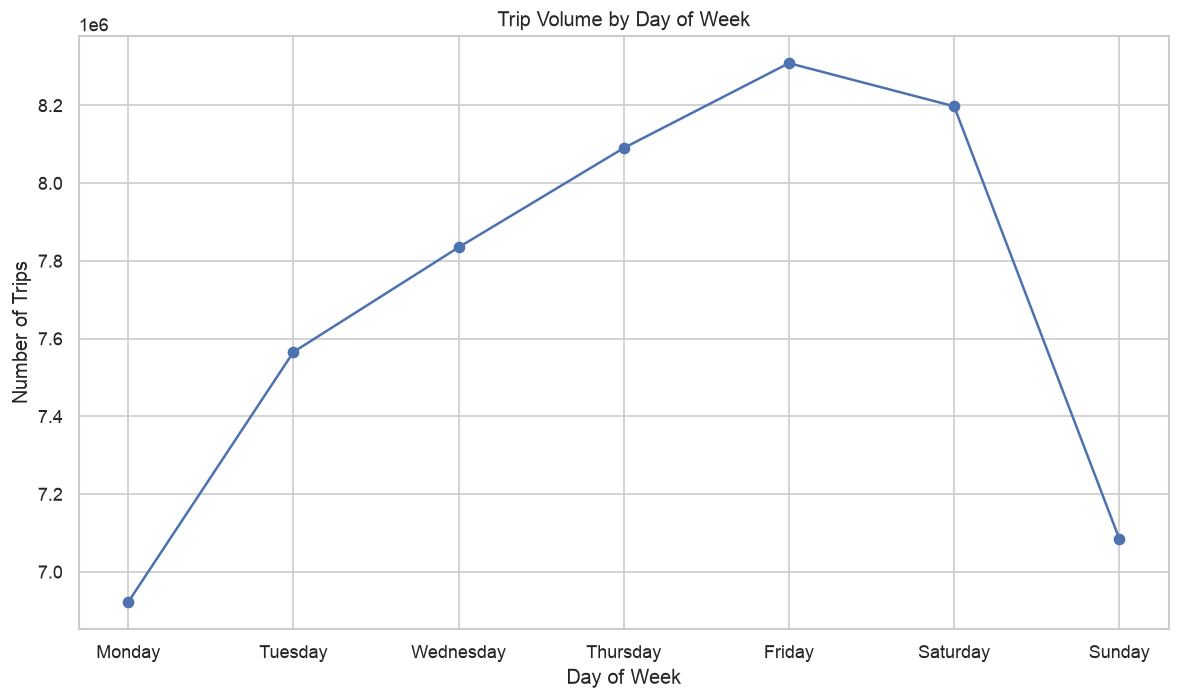

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(DAY_NAMES.values()),
    day_of_week_stats["trip_count"],
    marker="o",
)

plt.xlabel(
    "Day of Week"
)

plt.ylabel(
    "Number of Trips"
)

plt.title(
    "Trip Volume by Day of Week"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "trip_volume_by_day.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

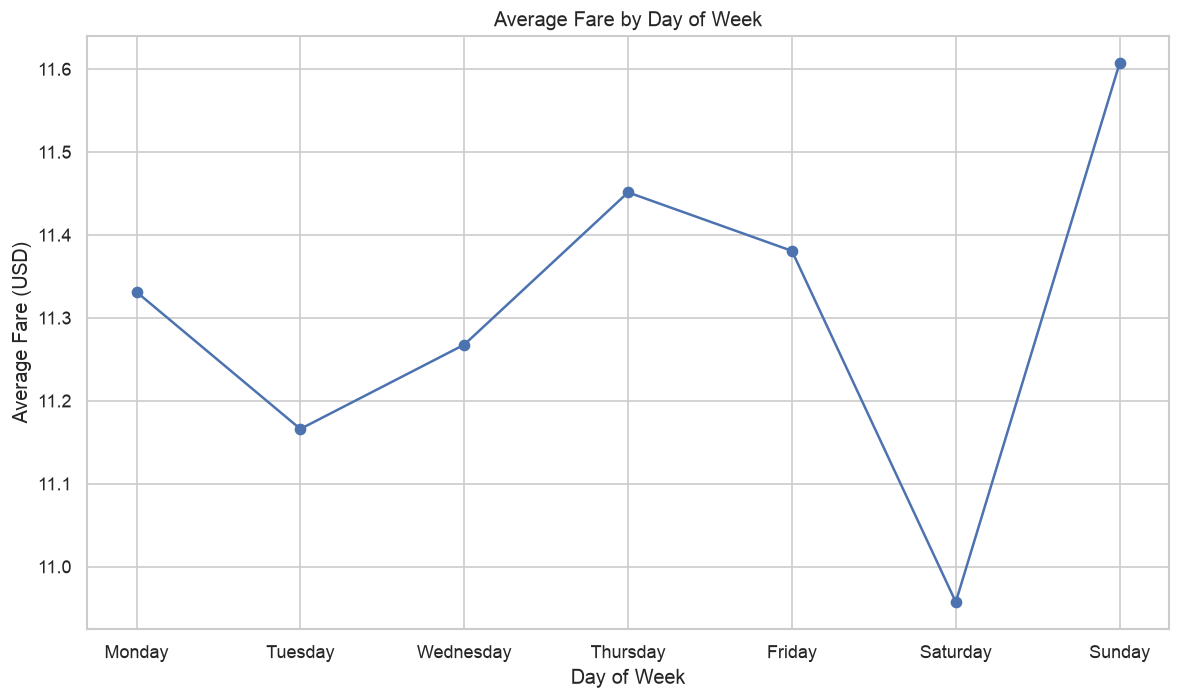

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(DAY_NAMES.values()),
    day_of_week_stats["avg_fare"],
    marker="o",
)

plt.xlabel(
    "Day of Week"
)

plt.ylabel(
    "Average Fare (USD)"
)

plt.title(
    "Average Fare by Day of Week"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "average_fare_by_day.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

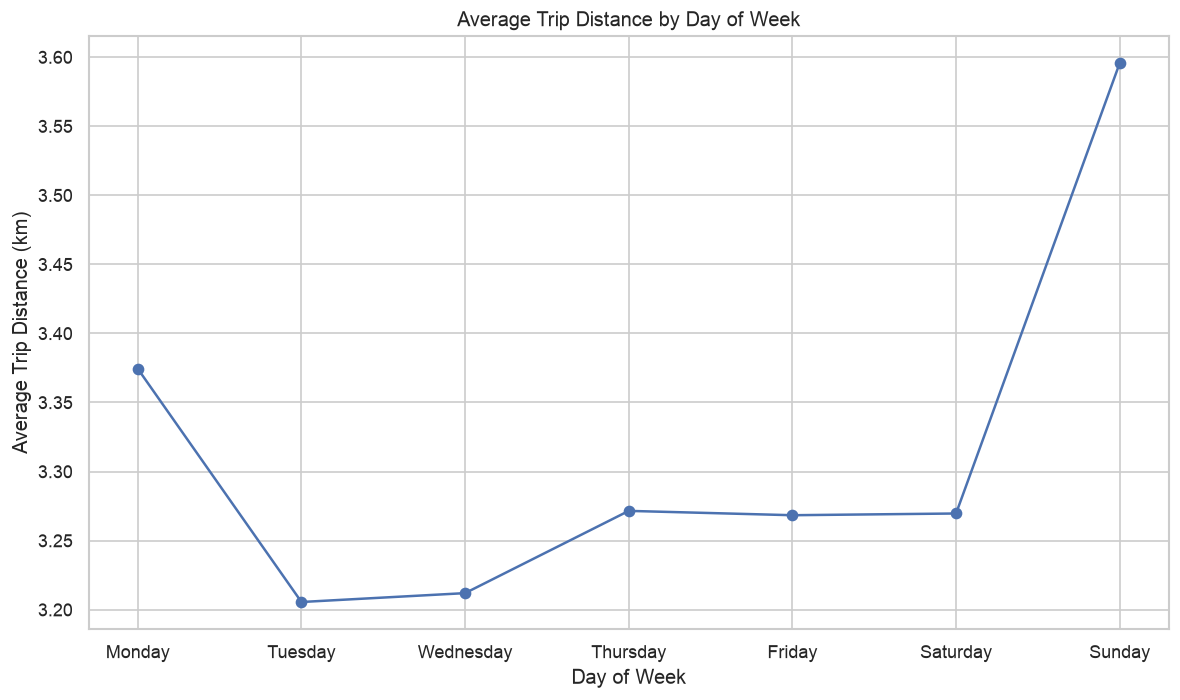

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(DAY_NAMES.values()),
    day_of_week_stats["avg_distance"],
    marker="o",
)

plt.xlabel(
    "Day of Week"
)

plt.ylabel(
    "Average Trip Distance (km)"
)

plt.title(
    "Average Trip Distance by Day of Week"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "average_distance_by_day.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Key Finding

Trip demand varies across the week, increasing from 6.92 million trips on
Monday to a peak of 8.31 million on Friday. Saturday remains busy, while
demand falls to 7.09 million on Sunday.

Average fares vary within a relatively narrow range of $10.96–$11.61. Sunday
has both the highest average fare and the longest average trip distance
(3.60 km), so the higher Sunday fare coincides with longer trips. However,
the pattern is not consistent across every day, indicating that average trip
distance alone does not explain all day-of-week fare variation.

## Weekday vs Weekend

This comparison examines whether broader temporal patterns differ between
weekdays and weekends.

The analysis considers trip volume, average fare, and average trip distance.
Statistics are calculated from the full feature dataset using the corrected
`is_weekend` field.

In [24]:
WEEKDAY_WEEKEND_STATS_PATH = Path(
    "../reports/weekday_weekend_stats.csv"
)

WEEKEND_NAMES = {
    0: "Weekday",
    1: "Weekend",
}


def compute_weekday_weekend_statistics(
    path,
    chunksize=1_000_000,
):
    """Compute exact weekday/weekend statistics in chunks."""

    parts = []

    for i, chunk in enumerate(
        pd.read_csv(
            path,
            usecols=[
                "is_weekend",
                "fare_amount",
                "trip_distance",
            ],
            chunksize=chunksize,
        ),
        start=1,
    ):
        grouped = (
            chunk
            .groupby("is_weekend")
            .agg(
                trip_count=("fare_amount", "size"),
                fare_sum=("fare_amount", "sum"),
                distance_sum=("trip_distance", "sum"),
            )
        )

        parts.append(grouped)
        print(f"Processed chunk {i}")

    stats = (
        pd.concat(parts)
        .groupby(level=0)
        .sum()
        .sort_index()
    )

    stats["avg_fare"] = (
        stats["fare_sum"]
        / stats["trip_count"]
    )

    stats["avg_distance"] = (
        stats["distance_sum"]
        / stats["trip_count"]
    )

    stats = stats[
        [
            "trip_count",
            "avg_fare",
            "avg_distance",
        ]
    ]

    stats.index = stats.index.map(
        WEEKEND_NAMES
    )
    stats.index.name = "group"

    return stats

In [25]:
if WEEKDAY_WEEKEND_STATS_PATH.exists():

    print("Loading existing weekday/weekend statistics...")

    weekday_weekend_stats = pd.read_csv(
        WEEKDAY_WEEKEND_STATS_PATH,
        index_col="group",
    )

else:

    print("Computing weekday/weekend statistics from full dataset...")

    weekday_weekend_stats = compute_weekday_weekend_statistics(
        DATA_PATH,
        chunksize=1_000_000,
    )

    weekday_weekend_stats.to_csv(
        WEEKDAY_WEEKEND_STATS_PATH
    )

    print(
        f"Saved to: {WEEKDAY_WEEKEND_STATS_PATH}"
    )


assert (
    weekday_weekend_stats["trip_count"].sum()
    == TOTAL_ROWS
)

weekday_weekend_stats.round(3)

Loading existing weekday/weekend statistics...


,trip_count,avg_fare,avg_distance
group,,,
Weekday,38721500,11.322,3.264
Weekend,15282858,11.259,3.421


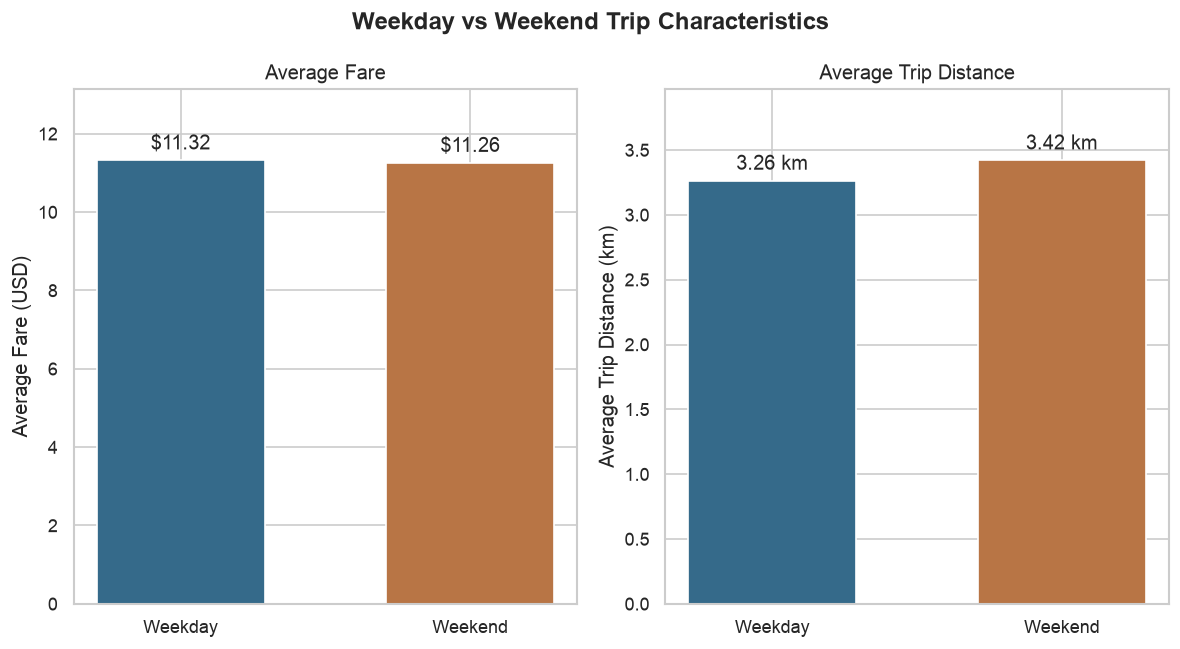

In [26]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5.5),
)

colors = [
    "#356A8A",
    "#B87545",
]

plot_specs = [
    (
        axes[0],
        "avg_fare",
        "Average Fare",
        "Average Fare (USD)",
        "${:.2f}",
    ),
    (
        axes[1],
        "avg_distance",
        "Average Trip Distance",
        "Average Trip Distance (km)",
        "{:.2f} km",
    ),
]

for ax, column, title, ylabel, value_format in plot_specs:
    bars = ax.bar(
        weekday_weekend_stats.index,
        weekday_weekend_stats[column],
        color=colors,
        width=0.58,
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(
        0,
        weekday_weekend_stats[column].max() * 1.16,
    )

    ax.bar_label(
        bars,
        labels=[
            value_format.format(value)
            for value in weekday_weekend_stats[column]
        ],
        padding=4,
    )

fig.suptitle(
    "Weekday vs Weekend Trip Characteristics",
    fontweight="bold",
)

fig.tight_layout()

plt.savefig(
    FIGURE_DIR / "weekday_vs_weekend.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Key Finding

The raw totals contain 38.72 million weekday trips and 15.28 million weekend
trips, but these groups cover five and two days of the week respectively.
On a comparable per-day-of-week basis, demand averages approximately 7.74
million trips for weekdays and 7.64 million for weekend days, a difference
of about 1.3%.

Weekend trips have a slightly lower average fare ($11.26 versus $11.32) but a
higher average trip distance (3.42 km versus 3.26 km). Because these metrics
move in opposite directions at this aggregate level, the small fare difference
cannot be explained by average distance alone. This is an association and does
not establish a causal weekend effect.

# Geographic Patterns

This section examines how taxi activity is distributed geographically across
New York City.

Unlike the earlier data-quality analysis, which focused on identifying invalid
coordinates, this analysis focuses on the spatial concentration of valid taxi
trips.

Because the dataset contains more than 54 million trips, geographic density is
calculated using full-dataset two-dimensional spatial aggregation rather than
plotting individual trip coordinates.

## Full-Dataset Spatial Aggregation

Pickup and drop-off coordinates are aggregated into the same 250 × 250 grid
over the geographic bounds used by the cleaning pipeline. The cached density
matrices allow subsequent notebook runs to reproduce the analysis without
rescanning the full feature dataset.

In [27]:
import sys


SRC_DIR = Path("../src").resolve()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


from geographic_analysis import (
    NYC_LAT_MAX,
    NYC_LAT_MIN,
    NYC_LON_MAX,
    NYC_LON_MIN,
    compute_concentration,
    compute_geographic_density,
    compute_spatial_correlation,
    create_density_norm,
    load_density_grids,
    plot_density,
    plot_density_comparison,
    save_density_grids,
    save_hotspots,
    validate_density_grids,
)


GEOGRAPHIC_DENSITY_PATH = Path(
    "../reports/geographic_density.npz"
)

GEOGRAPHIC_HOTSPOTS_PATH = Path(
    "../reports/geographic_hotspots.csv"
)

GEOGRAPHIC_GRID_SIZE = 250

In [28]:
if GEOGRAPHIC_DENSITY_PATH.exists():

    print("Loading cached geographic density grids...")

    geographic_density = load_density_grids(
        GEOGRAPHIC_DENSITY_PATH
    )

else:

    print("Computing geographic density from full dataset...")

    geographic_density = compute_geographic_density(
        DATA_PATH,
        grid_size=GEOGRAPHIC_GRID_SIZE,
        chunksize=1_000_000,
    )

    validate_density_grids(
        geographic_density,
        expected_rows=TOTAL_ROWS,
    )

    save_density_grids(
        GEOGRAPHIC_DENSITY_PATH,
        geographic_density,
    )


geographic_validation = validate_density_grids(
    geographic_density,
    expected_rows=TOTAL_ROWS,
)

pickup_density = geographic_density["pickup_density"]
dropoff_density = geographic_density["dropoff_density"]
lon_edges = geographic_density["lon_edges"]
lat_edges = geographic_density["lat_edges"]


print("=== Geographic Aggregation Validation ===")
print(f"Full dataset rows: {geographic_validation['total_rows']:,}")
print(f"Pickup grid total: {geographic_validation['pickup_total']:,}")
print(f"Drop-off grid total: {geographic_validation['dropoff_total']:,}")
print(f"Pickup difference: {geographic_validation['pickup_difference']:,}")
print(f"Drop-off difference: {geographic_validation['dropoff_difference']:,}")
print(f"Grid resolution: {pickup_density.shape[0]} × {pickup_density.shape[1]}")
print(f"Longitude range: [{lon_edges[0]}, {lon_edges[-1]}]")
print(f"Latitude range: [{lat_edges[0]}, {lat_edges[-1]}]")

Loading cached geographic density grids...
=== Geographic Aggregation Validation ===
Full dataset rows: 54,004,358
Pickup grid total: 54,004,358
Drop-off grid total: 54,004,358
Pickup difference: 0
Drop-off difference: 0
Grid resolution: 250 × 250
Longitude range: [-74.3, -73.7]
Latitude range: [40.5, 41.0]


In [29]:
spatial_corr = compute_spatial_correlation(
    pickup_density,
    dropoff_density,
)

pickup_concentration = compute_concentration(
    pickup_density
)

dropoff_concentration = compute_concentration(
    dropoff_density
)


print(
    "Pickup–drop-off spatial density correlation: "
    f"{spatial_corr:.4f}"
)

print("\n=== Spatial Grid Concentration ===")

for percentage in (0.01, 0.05, 0.10):
    print(
        f"Top {percentage:.0%} densest cells: "
        f"pickup={pickup_concentration[percentage]:.2%}, "
        f"drop-off={dropoff_concentration[percentage]:.2%}"
    )

Pickup–drop-off spatial density correlation: 0.9625

=== Spatial Grid Concentration ===
Top 1% densest cells: pickup=92.40%, drop-off=84.58%
Top 5% densest cells: pickup=99.51%, drop-off=97.99%
Top 10% densest cells: pickup=99.78%, drop-off=99.19%


## Pickup Density

The pickup map uses the full-dataset grid with logarithmic color normalization
so that both dominant activity areas and lower-density spatial structure remain
visible.

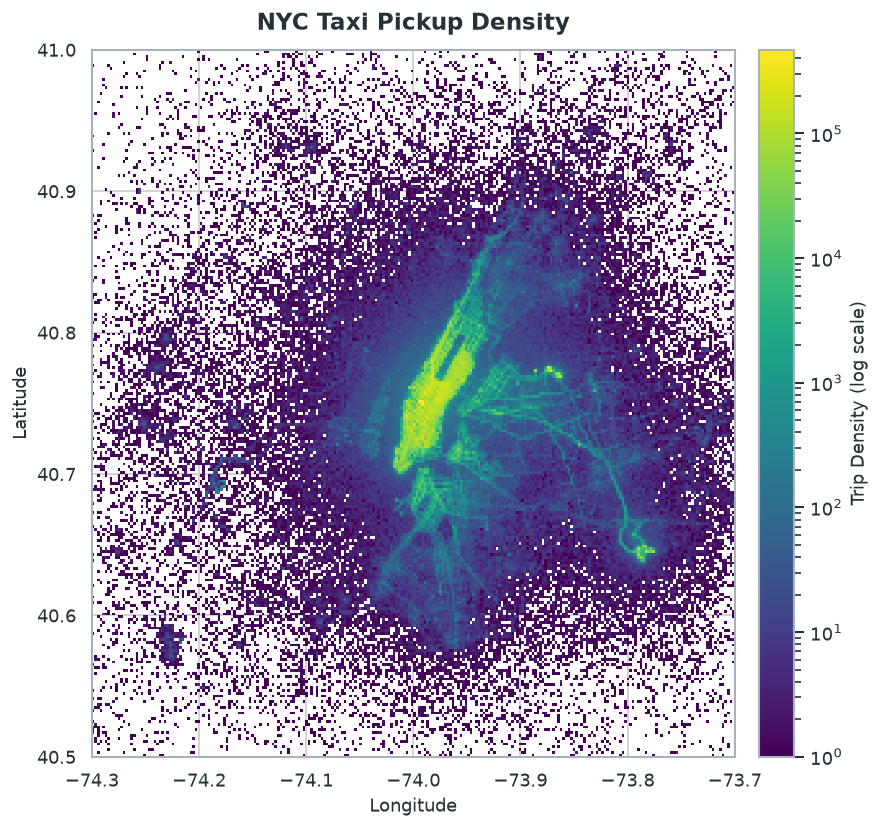

In [30]:
shared_density_norm = create_density_norm(
    pickup_density,
    dropoff_density,
)

pickup_figure = plot_density(
    pickup_density,
    lon_edges,
    lat_edges,
    title="NYC Taxi Pickup Density",
    output_path=(
        FIGURE_DIR
        / "pickup_trip_density.png"
    ),
    norm=shared_density_norm,
)

plt.show()
plt.close(pickup_figure)

## Drop-off Density

The drop-off map uses exactly the same bounds, grid resolution, and logarithmic
density scale as the pickup map, allowing direct visual comparison.

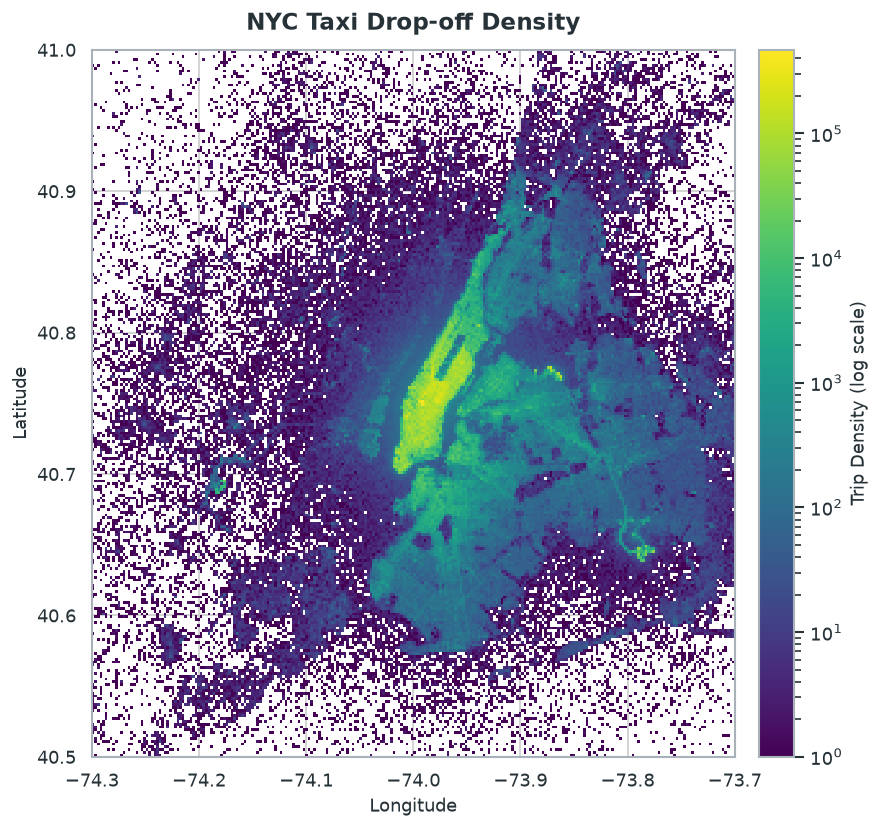

In [31]:
dropoff_figure = plot_density(
    dropoff_density,
    lon_edges,
    lat_edges,
    title="NYC Taxi Drop-off Density",
    output_path=(
        FIGURE_DIR
        / "dropoff_trip_density.png"
    ),
    norm=shared_density_norm,
)

plt.show()
plt.close(dropoff_figure)

## Pickup vs Drop-off Comparison

The side-by-side view applies one shared color scale. Differences in apparent
coverage therefore reflect the aggregated data rather than separate visual
normalization.

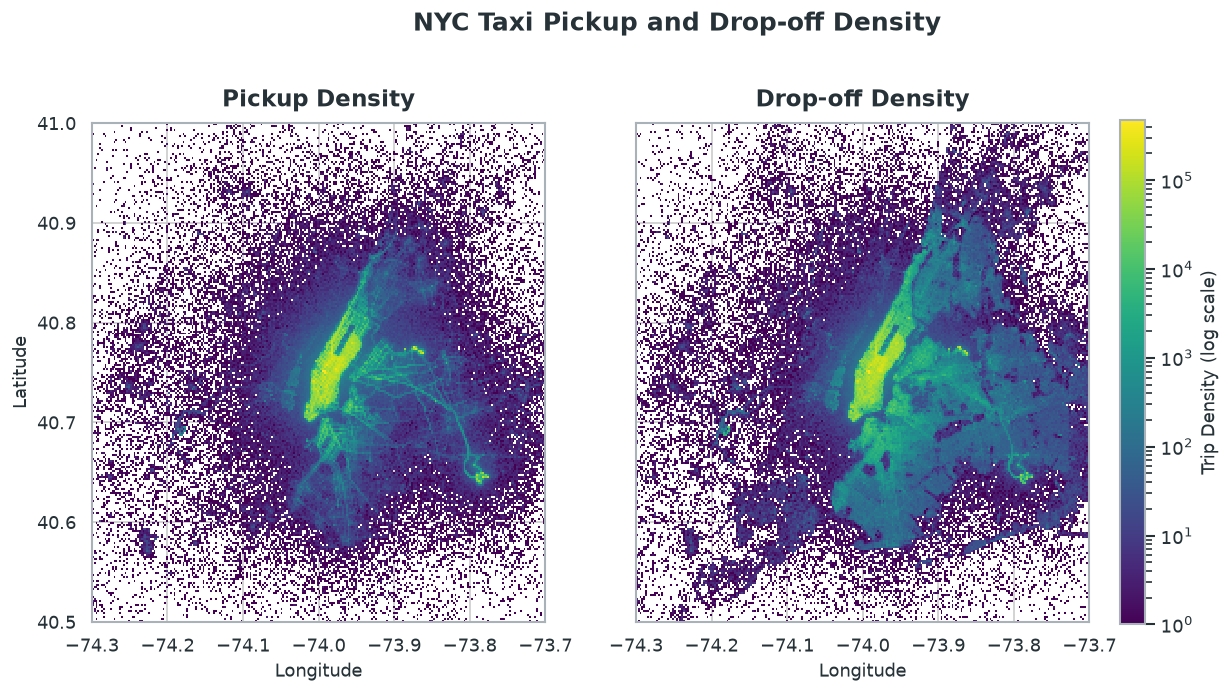

In [32]:
comparison_figure = plot_density_comparison(
    pickup_density,
    dropoff_density,
    lon_edges,
    lat_edges,
    output_path=(
        FIGURE_DIR
        / "pickup_dropoff_density_comparison.png"
    ),
    norm=shared_density_norm,
)

plt.show()
plt.close(comparison_figure)

## Geographic Hotspots

The table reports centers of the five densest grid cells for pickups and
drop-offs. These coordinates are approximate grid-cell centers rather than
precise addresses.

In [33]:
if GEOGRAPHIC_HOTSPOTS_PATH.exists():

    geographic_hotspots = pd.read_csv(
        GEOGRAPHIC_HOTSPOTS_PATH
    )

else:

    geographic_hotspots = save_hotspots(
        GEOGRAPHIC_HOTSPOTS_PATH,
        pickup_density,
        dropoff_density,
        lon_edges,
        lat_edges,
        top_n=5,
    )


geographic_hotspots

,type,rank,longitude,latitude,trip_count
0,pickup,1,-73.9940,40.751,436605
1,pickup,2,-73.9916,40.751,421382
2,pickup,3,-73.9916,40.749,384784
3,pickup,4,-73.9892,40.757,320430
4,pickup,5,-73.9772,40.753,312908
5,dropoff,1,-73.9916,40.751,469586
6,dropoff,2,-73.9916,40.749,388172
7,dropoff,3,-73.9940,40.751,248132
8,dropoff,4,-73.9772,40.751,245307
9,dropoff,5,-73.9892,40.757,232114


### Key Finding

Taxi activity is highly concentrated within the fixed 62,500-cell spatial
grid. The densest 1% of cells contain 92.40% of pickups and 84.58% of
drop-offs; the corresponding top-5% shares are 99.51% and 97.99%.

Pickup and drop-off density patterns are strongly associated at the grid level
(Pearson correlation 0.9625), and their five highest-density cells all fall
within the same compact central Manhattan area. Drop-offs are nevertheless more
spatially dispersed: 39,740 drop-off cells contain activity, compared with
35,382 pickup cells, and their concentration shares are lower at each threshold.
Several isolated high-density outer-area cells are also visible, but grid
coordinates alone do not establish specific place identities.

These localized origin and destination patterns indicate that geographic
features may add predictive information beyond trip distance and time alone,
for example by representing different pickup and drop-off activity regimes.
This analysis describes spatial association and does not imply causation.

# Feature Engineering Summary

This addition documents the existing definitions in `src/features.py`; it does not change the feature pipeline or repeat the completed Distance, Temporal, or Geographic EDA.

| Feature name | Source / how it is generated | Business meaning | Why it is selected |
|---|---|---|---|
| `trip_distance` | Haversine formula on pickup/drop-off coordinates; Earth radius 6371.0088 km | Straight-line trip length in km, not driven road distance | Strong observed fare relationship; proxy for distance travelled |
| `pickup_hour` | Parse `pickup_datetime` with `utc=True`, then `.dt.hour` (0–23); preserve original clock time without New York timezone conversion | Time of day when the trip begins | Captures grouped daily fare/demand patterns; hour is cyclic |
| `day_of_week` | Parsed datetime `.dt.dayofweek`: Monday=0, Sunday=6 | Weekly travel schedule | Captures weekday-specific patterns; integer codes do not imply a linear fare trend |
| `is_weekend` | `(day_of_week >= 5).astype("int8")` | Saturday/Sunday indicator | Compact weekday/weekend comparison; derived from and redundant with day of week |
| `passenger_count` | Existing cleaned passenger count | Recorded party size | Candidate for group-travel differences; relevance must be assessed empirically |
| `pickup_longitude` | Existing cleaned origin longitude in degrees | East–west origin location | Represents spatial trip context and localized pickup patterns |
| `pickup_latitude` | Existing cleaned origin latitude in degrees | North–south origin location | Complements origin longitude for spatial context |
| `dropoff_longitude` | Existing cleaned destination longitude in degrees | East–west destination location | Represents destination context and localized drop-off patterns |
| `dropoff_latitude` | Existing cleaned destination latitude in degrees | North–south destination location | Complements destination longitude for spatial context |

`fare_amount` is the target, never an input feature. `key` is a record identifier and is excluded. The raw `pickup_datetime` string is not used as a model feature: only its derived temporal features are considered. Selection here means candidates for later validation, not demonstrated incremental predictive benefit.

## Comprehensive Correlation Analysis

Use all nine candidate features plus the target from the existing reproducible 300,000-row EDA sample. Pearson measures linear association; Spearman target correlations provide a monotonic comparison. No row filtering is introduced: fail explicitly if selected values are missing or non-finite.

Low Pearson correlation of binary, categorical or time-coded fields does not establish lack of value. Hour and day codes have cyclic/grouped meaning; spatial effects can be localized and nonlinear. The heatmap also exposes redundancy among inputs, especially `day_of_week` and its derived `is_weekend` flag.

Correlation sample: 300,000 rows; no additional filtering


,pearson_r,spearman_r
feature,,
trip_distance,0.853522,0.846578
pickup_hour,-0.019986,-0.006467
day_of_week,0.002303,0.011906
is_weekend,-0.004206,0.000712
passenger_count,0.013191,0.020539
pickup_longitude,0.418694,0.044013
pickup_latitude,-0.214166,-0.077598
dropoff_longitude,0.298362,0.105978
dropoff_latitude,-0.173472,-0.089514


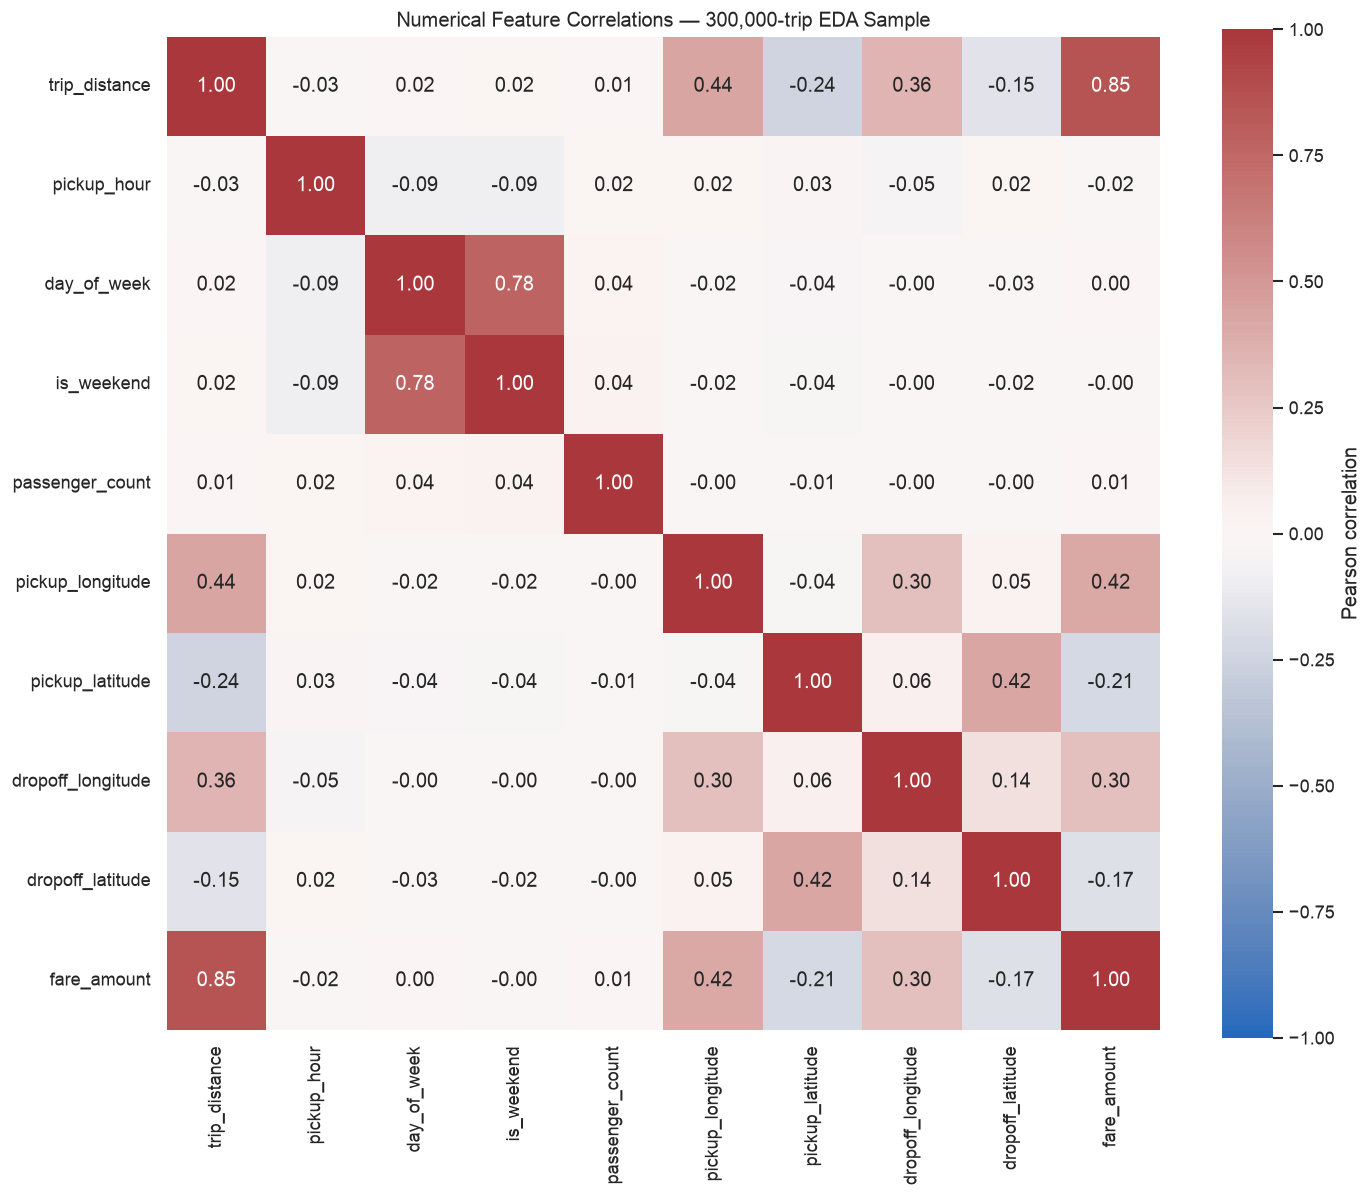

In [3]:
FEATURE_COLUMNS = [
    "trip_distance", "pickup_hour", "day_of_week", "is_weekend",
    "passenger_count", "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude",
]
TARGET_COLUMN = "fare_amount"
REPORT_DIR = FIGURE_DIR.parent.parent
feature_data = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
assert len(feature_data) == TARGET_SAMPLE_SIZE
assert np.isfinite(feature_data.to_numpy()).all(), "Missing/non-finite analysis values"
assert "key" not in feature_data and "pickup_datetime" not in feature_data

correlation_matrix = feature_data.corr(method="pearson")
target_correlations = pd.DataFrame({
    "pearson_r": correlation_matrix.loc[FEATURE_COLUMNS, TARGET_COLUMN],
    "spearman_r": feature_data.corr(method="spearman").loc[FEATURE_COLUMNS, TARGET_COLUMN],
})
target_correlations.index.name = "feature"
correlation_matrix.to_csv(REPORT_DIR / "feature_correlation_matrix.csv")
target_correlations.to_csv(REPORT_DIR / "feature_target_correlations.csv")
print(f"Correlation sample: {len(feature_data):,} rows; no additional filtering")
display(target_correlations.round(6))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag",
            vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Numerical Feature Correlations — 300,000-trip EDA Sample")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "feature_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

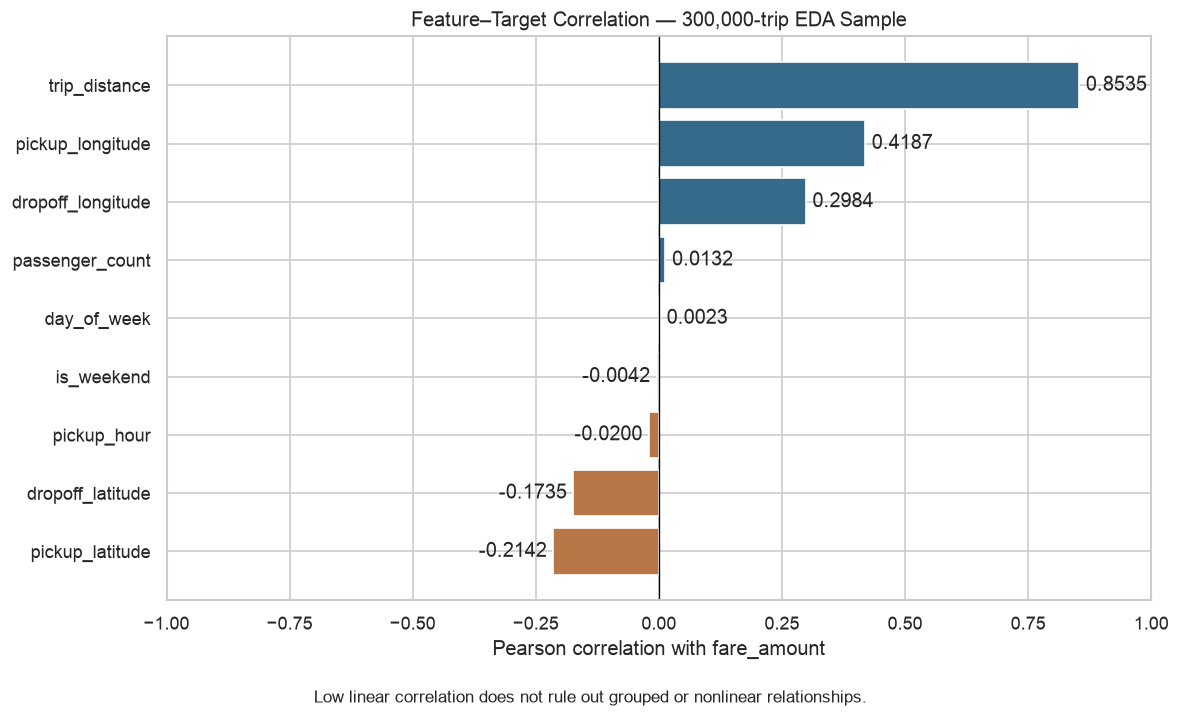

In [4]:
ordered_r = target_correlations["pearson_r"].sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ordered_r.index, ordered_r.values,
               color=["#B87545" if v < 0 else "#356A8A" for v in ordered_r])
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel("Pearson correlation with fare_amount")
ax.set_title("Feature–Target Correlation — 300,000-trip EDA Sample")
fig.text(0.5, 0.01, "Low linear correlation does not rule out grouped or nonlinear relationships.",
         ha="center", fontsize=10)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIGURE_DIR / "feature_target_correlation.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## Feature Relevance Analysis — Mutual Information

Compute model-independent, univariate Mutual Information (MI) using `sklearn.feature_selection.mutual_info_regression`. The sample is a fixed 50,000-row subsample of the existing EDA sample (`random_state=42`); the estimator also uses seed 42 and `n_neighbors=5`. Hours, day codes, weekend flags and passenger counts are explicitly marked discrete; distance and coordinates are continuous. No train/test split or predictive model is fitted.

MI is nonnegative and measured in nats. It can detect nonlinear dependence but has no direction and is not a percentage of explained fare variation. Estimates depend on sampling and estimator settings; small or zero estimates do not prove independence. This univariate analysis does not measure conditional contributions, interactions, causality or out-of-sample predictive gain. Correlated or derived features may contain overlapping information. This is **Feature Relevance**, not formal **Model Feature Importance**; Random Forest / Gradient Boosting importance belongs to Week 3.

MI sample: 50,000; seed=42; sklearn=1.9.0


,pearson_r,spearman_r,mutual_information_nats,mi_discrete_feature
feature,,,,
trip_distance,0.853522,0.846578,0.910073,False
dropoff_longitude,0.298362,0.105978,0.118138,False
dropoff_latitude,-0.173472,-0.089514,0.104760,False
pickup_longitude,0.418694,0.044013,0.098983,False
pickup_latitude,-0.214166,-0.077598,0.080848,False
pickup_hour,-0.019986,-0.006467,0.012990,True
passenger_count,0.013191,0.020539,0.007275,True
day_of_week,0.002303,0.011906,0.000366,True
is_weekend,-0.004206,0.000712,0.000000,True


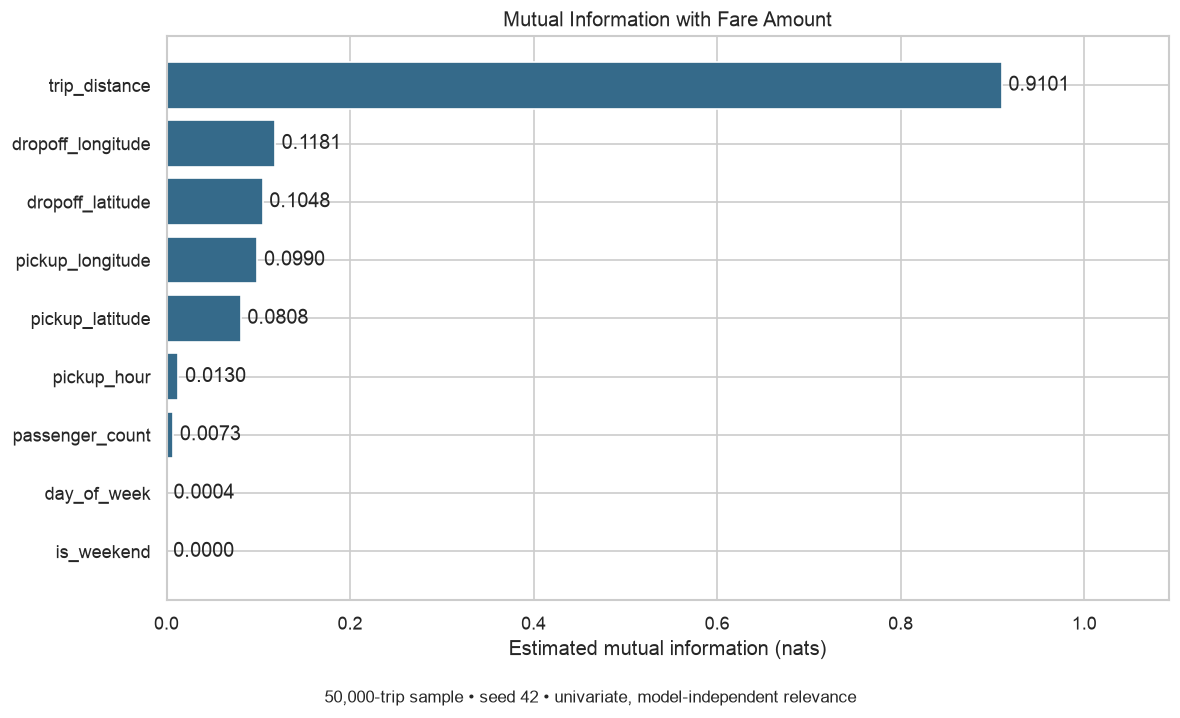

In [5]:
import sklearn
from sklearn.feature_selection import mutual_info_regression

MI_SAMPLE_SIZE = 50_000
MI_NEIGHBORS = 5
DISCRETE_FEATURES = {"pickup_hour", "day_of_week", "is_weekend", "passenger_count"}
mi_sample = feature_data.sample(n=MI_SAMPLE_SIZE, random_state=RANDOM_STATE)
discrete_mask = [name in DISCRETE_FEATURES for name in FEATURE_COLUMNS]
for name in DISCRETE_FEATURES:
    assert (mi_sample[name] == np.floor(mi_sample[name])).all()

mi_values = mutual_info_regression(
    mi_sample[FEATURE_COLUMNS], mi_sample[TARGET_COLUMN],
    discrete_features=discrete_mask, n_neighbors=MI_NEIGHBORS,
    random_state=RANDOM_STATE,
)
feature_relevance = target_correlations.join(
    pd.Series(mi_values, index=FEATURE_COLUMNS, name="mutual_information_nats")
)
feature_relevance["mi_discrete_feature"] = discrete_mask
feature_relevance.to_csv(REPORT_DIR / "feature_relevance.csv")

# Persist the analysis settings and sampled row positions for reproducibility.
import hashlib
import json
metadata = {
    "eda_sample_rows": len(feature_data), "mi_sample_rows": len(mi_sample),
    "random_state": RANDOM_STATE, "n_neighbors": MI_NEIGHBORS,
    "sklearn_version": sklearn.__version__, "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "eda_sample_sha256": hashlib.sha256(EDA_SAMPLE_PATH.read_bytes()).hexdigest(),
    "features": FEATURE_COLUMNS, "discrete_features": sorted(DISCRETE_FEATURES),
    "target": TARGET_COLUMN, "mi_units": "nats",
}
(REPORT_DIR / "feature_relevance_metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
pd.Series(mi_sample.index, name="eda_sample_row_position").to_csv(
    REPORT_DIR / "feature_relevance_sample_indices.csv", index=False
)
print(f"MI sample: {len(mi_sample):,}; seed={RANDOM_STATE}; sklearn={sklearn.__version__}")
display(feature_relevance.sort_values("mutual_information_nats", ascending=False).round(6))

ordered_mi = feature_relevance["mutual_information_nats"].sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ordered_mi.index, ordered_mi.values, color="#356A8A")
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.set_xlim(0, ordered_mi.max() * 1.2)
ax.set_xlabel("Estimated mutual information (nats)")
ax.set_title("Mutual Information with Fare Amount")
fig.text(0.5, 0.01, "50,000-trip sample • seed 42 • univariate, model-independent relevance",
         ha="center", fontsize=10)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIGURE_DIR / "feature_relevance.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## Passenger Count — Full-Dataset Aggregation

Read all rows of `train_features.csv` in chunks and aggregate `passenger_count → trip_count, average_fare, average_distance`. Sum fares and distances before dividing by the total group count (do not average chunk means). Validate completeness and finite inputs without modifying or filtering the source data. Display counts and trip shares to make group imbalance visible. Fare and distance averages are descriptive associations, not a distance-adjusted passenger effect.

In [6]:
def compute_passenger_statistics(path, chunksize=1_000_000):
    parts = []
    rows_seen = 0
    for chunk in pd.read_csv(
        path, usecols=["passenger_count", "fare_amount", "trip_distance"],
        chunksize=chunksize,
    ):
        assert np.isfinite(chunk.to_numpy()).all(), "Invalid aggregation values"
        parts.append(chunk.groupby("passenger_count").agg(
            trip_count=("fare_amount", "size"),
            fare_sum=("fare_amount", "sum"),
            distance_sum=("trip_distance", "sum"),
        ))
        rows_seen += len(chunk)
    stats = pd.concat(parts).groupby(level=0).sum().sort_index()
    assert rows_seen == TOTAL_ROWS
    assert stats["trip_count"].sum() == rows_seen
    stats["average_fare"] = stats["fare_sum"] / stats["trip_count"]
    stats["average_distance"] = stats["distance_sum"] / stats["trip_count"]
    stats["trip_share"] = stats["trip_count"] / rows_seen
    return stats[["trip_count", "average_fare", "average_distance", "trip_share"]]

# Always scan the full source for this addition; do not reuse unverified caches.
passenger_stats = compute_passenger_statistics(DATA_PATH)
passenger_stats.to_csv(REPORT_DIR / "passenger_count_stats.csv")
print(f"Full-dataset aggregation: {passenger_stats['trip_count'].sum():,} trips")
display(passenger_stats.round(6))


Full-dataset aggregation: 54,004,358 trips


,trip_count,average_fare,average_distance,trip_share
passenger_count,,,,
1,37476021,11.160826,3.258055,0.693944
2,8004688,11.790127,3.491049,0.148223
3,2380495,11.499571,3.362816,0.044080
4,1154398,11.714048,3.420335,0.021376
5,3838893,11.199092,3.330272,0.071085
6,1149799,12.111480,3.387080,0.021291
7,13,35.679231,5.168668,0.000000
8,7,37.047143,3.502856,0.000000
9,21,39.968571,4.591823,0.000000


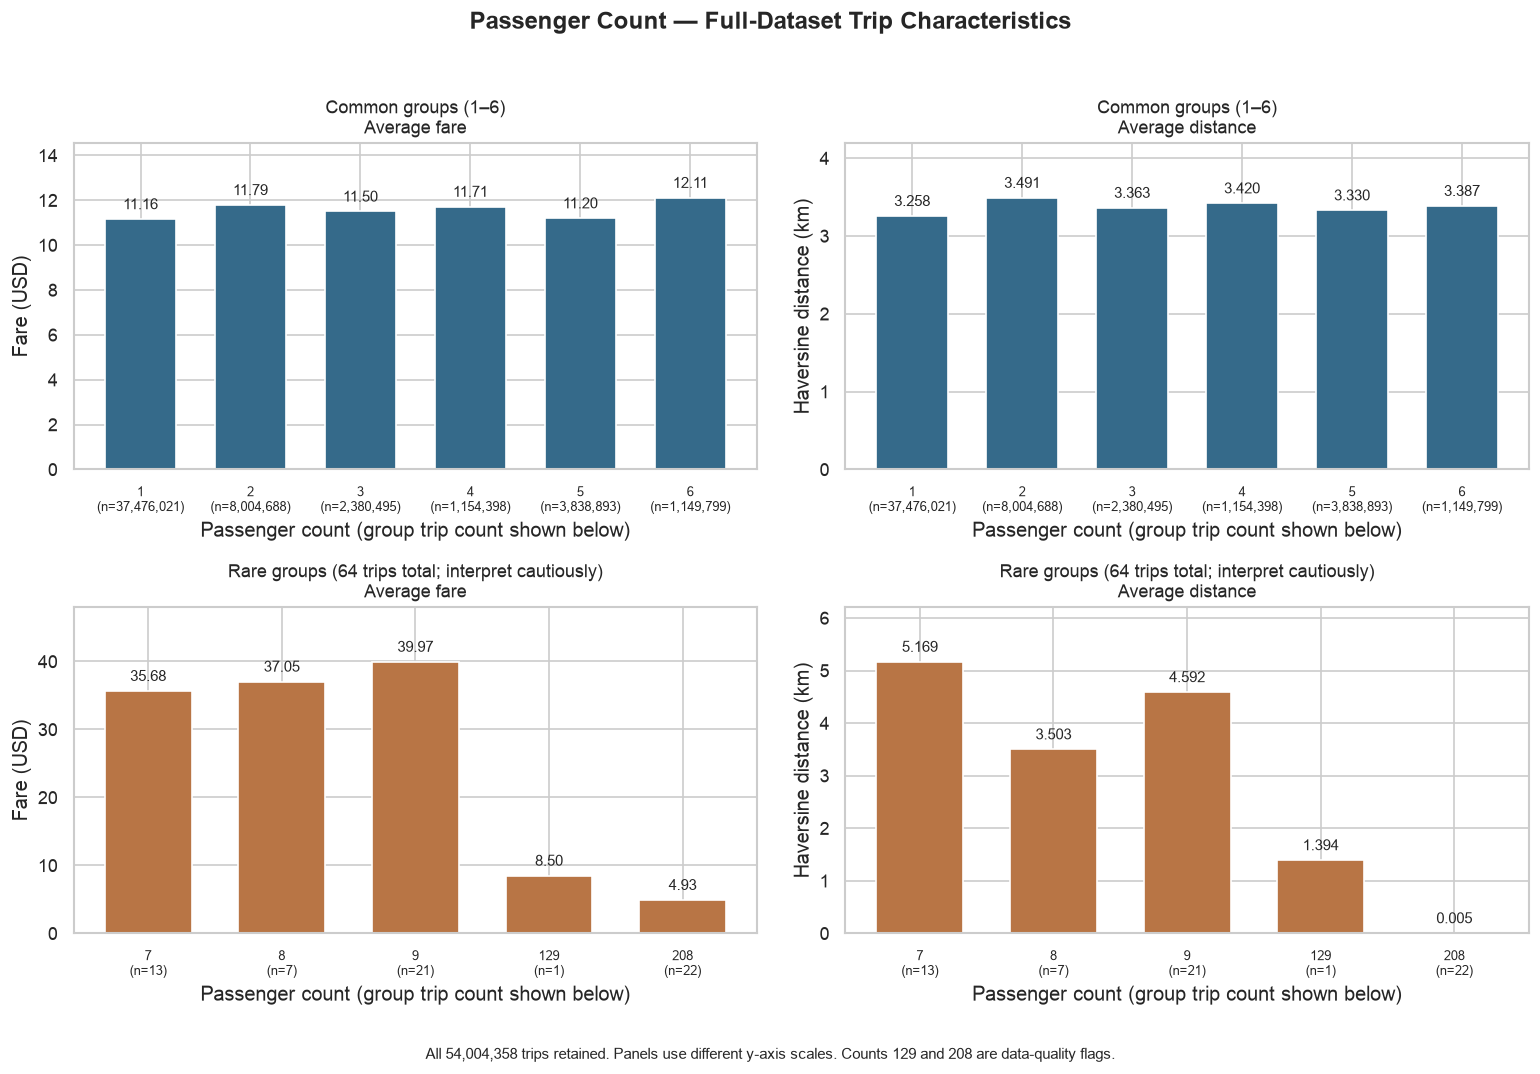

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, (group_label, subset, color) in enumerate([
    ("Common groups (1–6)", passenger_stats.loc[1:6], "#356A8A"),
    ("Rare groups (64 trips total; interpret cautiously)", passenger_stats.loc[passenger_stats.index > 6], "#B87545"),
]):
    labels = [f"{i}\n(n={int(r.trip_count):,})" for i, r in subset.iterrows()]
    for col, (column, title, ylabel) in enumerate([
        ("average_fare", "Average fare", "Fare (USD)"),
        ("average_distance", "Average distance", "Haversine distance (km)"),
    ]):
        ax = axes[row, col]
        bars = ax.bar(labels, subset[column], color=color, width=0.65)
        ax.bar_label(bars, fmt="%.3f" if column == "average_distance" else "%.2f", padding=4, fontsize=9)
        ax.set_ylim(0, subset[column].max() * 1.2)
        ax.set_title(f"{group_label}\n{title}", fontsize=11)
        ax.set_xlabel("Passenger count (group trip count shown below)")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Passenger Count — Full-Dataset Trip Characteristics", fontweight="bold")
fig.text(0.5, 0.01, "All 54,004,358 trips retained. Panels use different y-axis scales. Counts 129 and 208 are data-quality flags.",
         ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
fig.savefig(FIGURE_DIR / "average_fare_by_passenger_count.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## Feature Relevance — Interpretation

| Feature | Pearson r (300k) | MI in nats (50k) |
|---|---:|---:|
| `trip_distance` | 0.8535 | 0.9101 |
| `pickup_hour` | -0.0200 | 0.0130 |
| `day_of_week` | 0.0023 | 0.0004 |
| `is_weekend` | -0.0042 | 0.0000 |
| `passenger_count` | 0.0132 | 0.0073 |
| `pickup_longitude` | 0.4187 | 0.0990 |
| `pickup_latitude` | -0.2142 | 0.0808 |
| `dropoff_longitude` | 0.2984 | 0.1181 |
| `dropoff_latitude` | -0.1735 | 0.1048 |

Distance has the strongest linear and monotonic fare association (Pearson **0.8535**, Spearman **0.8466**) and the highest MI (**0.9101**). The four coordinate fields follow in univariate MI (**0.0808–0.1181**); `dropoff_longitude` has the highest coordinate MI even though `pickup_longitude` has the highest coordinate Pearson correlation. This difference, together with the highly concentrated spatial patterns, shows why Pearson alone is insufficient for assessing geography. Coordinate–distance associations also imply overlapping information; incremental geographic value remains untested.

Temporal features have clear grouped/nonlinear patterns in the completed full-dataset EDA despite near-zero Pearson coefficients. `pickup_hour` has MI **0.0130**; `day_of_week` is **0.0004** and `is_weekend` is **0.0000** in this estimate. Small/zero MI estimates do not negate grouped patterns or establish lack of predictive value. The heatmap shows day-of-week/weekend correlation of about **0.78**, consistent with their deterministic derivation and potential redundancy.

Passenger count has weak observed univariate relevance (Pearson **0.0132**, Spearman **0.0205**, MI **0.0073**). Full aggregation retains **54,004,358** trips: one-passenger trips account for **69.39%**. For common groups 1–6, average fare is **$11.16–$12.11** and average distance **3.258–3.491 km**, with no consistent increase as passenger count rises. Two-passenger trips average **$11.79 / 3.491 km**, versus **$11.16 / 3.258 km** for one passenger; the higher fare coincides with greater distance. Six-passenger trips have the highest common-group fare (**$12.11**) but not the longest distance (**3.387 km**), so group means alone do not isolate a passenger effect.

There are only **64** records outside 1–6: 7 (13 trips), 8 (7), 9 (21), 129 (1), and 208 (22). Counts 129 and 208 are data-quality flags; all records are retained as requested. Sparse-group means are unsuitable for generalization. The plot separates common and rare groups and displays their counts; the CSV includes every group and its trip share. Neither rare-group extremes nor small positive MI demonstrate a robust incremental passenger effect.

For Week 3 validation, prioritize **trip_distance**, the **four coordinate fields**, and **pickup_hour**; retain day-of-week/weekend and passenger count as secondary candidates to assess redundancy and incremental value. This is a proposed validation priority, not model-based feature importance. No split, predictive model training, or Phase 3 analysis is performed here.


# Key Findings

1. **Distance is strongly associated with fare.** Trip distance has a
   Pearson correlation of 0.8535 and a Spearman correlation of 0.8466 with
   fare, making it the clearest fare-related variable examined so far.

2. **Demand and average fare peak at different times.** Trip volume is
   highest at 19:00 and lowest at 05:00, while 05:00 has the highest average
   fare and longest average distance. Early-morning fare levels therefore
   coincide with longer trips rather than higher demand.

3. **Weekly fare differences are modest relative to demand variation.**
   Friday is the busiest day and Sunday has the highest average fare. Weekend
   trips are approximately 4.8% longer but have a 0.6% lower average fare than
   weekday trips, so aggregated fare differences are not explained by
   distance alone.

4. **Taxi activity is highly spatially concentrated.** Within the fixed
   250 × 250 grid, the densest 1% of cells contain 92.40% of pickups and
   84.58% of drop-offs.

5. **Pickup and drop-off geography is similar but not identical.** Their
   grid-level density correlation is 0.9625, while drop-offs are more
   spatially dispersed. Geography may therefore add predictive information
   beyond distance and time in the next modelling phase.

6. **Feature engineering is explicit.** The summary documents nine candidate features, their origins, business meanings and selection rationale. `key` is excluded; raw `pickup_datetime` is converted to temporal fields rather than used directly.

7. **Nonlinear and grouped relevance requires more than Pearson.** Distance remains strongest (MI 0.9101); geographic MI is 0.0808–0.1181, and hourly MI is 0.0130 despite near-zero hourly Pearson correlation. Temporal grouped patterns and spatial concentration remain relevant evidence; low Pearson does not establish lack of value.

8. **Passenger count has weak observed univariate relevance.** Pearson is 0.0132 and MI is 0.0073. Common groups 1–6 average $11.16–$12.11 with non-monotonic fare and distance patterns; 69.39% of trips have one passenger. Only 64 trips have counts outside 1–6 (including 129 and 208); their means should not be generalized. All source records are retained.

9. **Model-independent relevance is not model-based importance.** MI measures univariate dependence, not incremental predictive contribution. Distance, coordinates and pickup hour are the leading candidates for Week 3 validation; weekly fields and passenger count remain secondary candidates. Formal model-based feature importance is deferred to Week 3.
